In [2]:
from IPython.display import HTML

from autosim.experimental.simulations import ReactionDiffusion
from autosim.utils import plot_spatiotemporal_video

## Dataset grid comparison

Load saved datasets from disk and display a snapshot from each in a tiled grid.
The bottom row spans the full width at half height for the 4:1 aspect-ratio dataset.

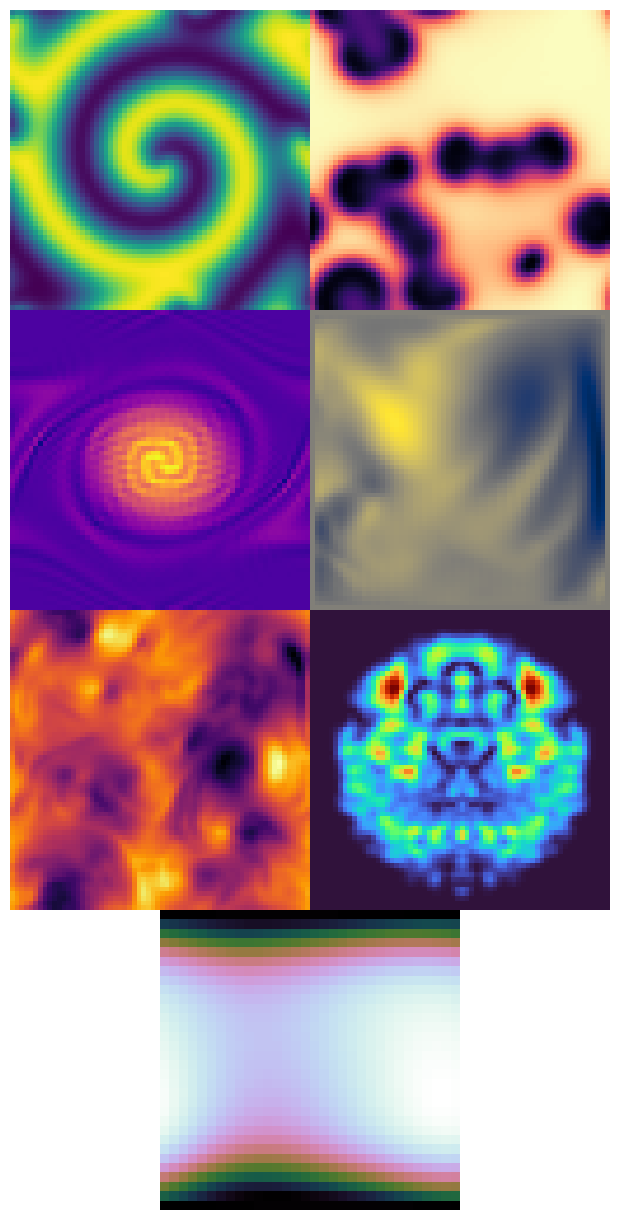

In [18]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from matplotlib.gridspec import GridSpec

# --- dataset list (imagine all 7 exist on disk; missing ones get a placeholder) ---
datasets = [
    ("reaction_diffusion_e3e8515", "Reaction-Diffusion", 0),
    ("gray_scott_68b0669", "Gray-Scott", 0),
    ("advection_diffusion_2ba25b9", "Advection-Diffusion", 0),
    ("conditioned_navier_stokes_2d_5e1f575", "Conditioned Navier-Stokes", 1),
    ("shallow_water2d_9057134", "Shallow Water", 1),
    ("gpe/laser_only_wake_9be0bfb", "GPE", 0),
    ("lattice_boltzmann_f530ec5", "Lattice Boltzmann", 1),
]

# Rotate colormaps to make each panel visually distinct.
cmaps = ["viridis", "magma", "plasma", "cividis", "inferno", "turbo", "cubehelix"]

base_dir = Path("generated_datasets")
batch_idx, time_idx, channel = 0, -1, 0  # which snapshot to show

# --- build grid: 3 rows x 2 cols + 1 bottom row ---
# figsize chosen so two square columns can sit flush without center gap.
fig = plt.figure(figsize=(6, 12))
fig.patch.set_alpha(0.0)
gs = GridSpec(4, 2, height_ratios=[1, 1, 1, 1], hspace=0.0, wspace=0.0)
base_dir = Path(os.getenv("AUTOCAST_DATASETS"))  # type: ignore  # noqa: PGH003

panel_width = None
panel_height = None

# first 6 datasets in 3x2
for i, (rel_path, name, channel) in enumerate(datasets[:6]):
    row, col = divmod(i, 2)
    ax = fig.add_subplot(gs[row, col])
    ax.patch.set_alpha(0.0)
    path = base_dir / rel_path / "train" / "data.pt"
    if path.exists():
        data = torch.load(path, weights_only=False)["data"]
        ax.imshow(
            data[batch_idx, time_idx, :, :, channel].numpy(),
            cmap=cmaps[i % len(cmaps)],
            aspect="equal",
        )
    ax.axis("off")

    if panel_width is None or panel_height is None:
        bbox = ax.get_position()
        panel_width = bbox.width
        panel_height = bbox.height

# 7th dataset — square crop and centered bottom placement with panel-matched size.
ax_lattice = fig.add_subplot(gs[3, :])
ax_lattice.patch.set_alpha(0.0)
bottom_bbox = ax_lattice.get_position()
if panel_width is not None and panel_height is not None:
    ax_lattice.set_position(
        [0.5 - panel_width / 2, bottom_bbox.y0, panel_width, panel_height]
    )

rel_path, name, channel = datasets[6]
path = base_dir / rel_path / "train" / "data.pt"
if path.exists():
    data = torch.load(path, weights_only=False)["data"]
    lattice_frame = data[batch_idx, time_idx, :, :, channel].numpy()
    h, w = lattice_frame.shape

    if w > h:
        x0 = (w - h) // 2
        lattice_frame = lattice_frame[:, x0 : x0 + h]
    elif h > w:
        y0 = (h - w) // 2
        lattice_frame = lattice_frame[y0 : y0 + w, :]

    ax_lattice.imshow(
        lattice_frame,
        cmap=cmaps[6 % len(cmaps)],
        aspect="equal",
    )
ax_lattice.axis("off")

fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, wspace=0.0, hspace=0.0)
plt.show()